In [2]:
import os 
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, confusion_matrix


file_path = "german_credit_data.csv"  # AJUSTE al nombre real que le salió en el listado

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "uciml/german-credit",
    file_path,
)

print(df.head())
print(df.shape)
print(df.columns)


c:\Users\Esteban Orozco G\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\Esteban Orozco G\AppData\Local\Temp\ipykernel_13240\3438340281.py:20: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


   Unnamed: 0  Age     Sex  Job Housing Saving accounts Checking account  \
0           0   67    male    2     own             NaN           little   
1           1   22  female    2     own          little         moderate   
2           2   49    male    1     own          little              NaN   
3           3   45    male    2    free          little           little   
4           4   53    male    2    free          little           little   

   Credit amount  Duration              Purpose  
0           1169         6             radio/TV  
1           5951        48             radio/TV  
2           2096        12            education  
3           7882        42  furniture/equipment  
4           4870        24                  car  
(1000, 10)
Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose'],
      dtype='object')


In [3]:
import sys
print(sys.executable)

%pip install -U scikit-learn
import sklearn
print(sklearn.__version__)


c:\Users\Esteban Orozco G\AppData\Local\Python\pythoncore-3.14-64\python.exe
Note: you may need to restart the kernel to use updated packages.
1.8.0


In [4]:
import os

os.makedirs("data/raw", exist_ok=True)
df.to_csv("data/raw/german_credit.csv", index=False)

#se realiza con el fin de tener un respaldo del dataset original y dejar de requerir la conexión a Kaggle para cargar el dataset en futuras ejecuciones del notebook.

In [5]:
df.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose'],
      dtype='object')

In [6]:
# Se observa que hay una columna "Unnamed: 0" que parece ser un índice. Se puede eliminar esta columna si no es necesaria para el análisis.
df = df.drop(columns=["Unnamed: 0"])

In [7]:
# extrae valores unicos de la columna housing
df["Housing"].unique()

array(['own', 'free', 'rent'], dtype=object)

In [8]:
df["Saving accounts"].value_counts()

Saving accounts
little        603
moderate      103
quite rich     63
rich           48
Name: count, dtype: int64

In [9]:
df["Credit amount"].describe()

count     1000.000000
mean      3271.258000
std       2822.736876
min        250.000000
25%       1365.500000
50%       2319.500000
75%       3972.250000
max      18424.000000
Name: Credit amount, dtype: float64

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1000 non-null   int64 
 1   Sex               1000 non-null   object
 2   Job               1000 non-null   int64 
 3   Housing           1000 non-null   object
 4   Saving accounts   817 non-null    object
 5   Checking account  606 non-null    object
 6   Credit amount     1000 non-null   int64 
 7   Duration          1000 non-null   int64 
 8   Purpose           1000 non-null   object
dtypes: int64(4), object(5)
memory usage: 70.4+ KB


In [11]:
#nueva columna "Age_group" con rangos de edad
bins = [0, 25, 35, 45, 55, 65, np.inf]
labels = ["0-25", "26-35", "36-45", "46-55", "56-65", "66+"]
df["Age_group"] = pd.cut(df["Age"], bins=bins, labels=labels)

In [12]:
print(df["Age_group"].value_counts().sort_index())

Age_group
0-25     190
26-35    398
36-45    226
46-55    115
56-65     53
66+       18
Name: count, dtype: int64


In [13]:
job_map = {
    0: "desempleado",
    1: "no cualificado",
    2: "cualificado",
    3: "muy cualificado"
}
df["Job_type"] = df["Job"].map(job_map)
print(df["Job_type"].value_counts().sort_index())

Job_type
cualificado        630
desempleado         22
muy cualificado    148
no cualificado     200
Name: count, dtype: int64


In [14]:
df["Purpose"].value_counts()

Purpose
car                    337
radio/TV               280
furniture/equipment    181
business                97
education               59
repairs                 22
domestic appliances     12
vacation/others         12
Name: count, dtype: int64

In [15]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Age_group', 'Job_type'],
      dtype='object')

In [16]:
df["Duration"].describe()

count    1000.000000
mean       20.903000
std        12.058814
min         4.000000
25%        12.000000
50%        18.000000
75%        24.000000
max        72.000000
Name: Duration, dtype: float64

In [17]:
bins = [0, 6, 12, 18, 24, 30, 36, 42, 48, 54, 60, 66, 72, np.inf]
labels = ["0-6", "7-12", "13-18", "19-24", "25-30", "31-36", "37-42", "43-48", "49-54",
          "55-60", "61-66", "67-72", "73+"]
df["Duration_estimated"] = pd.cut(df["Duration"], bins=bins, labels=labels)

In [18]:
df['Duration_estimated'].value_counts().sort_index()

Duration_estimated
0-6       82
7-12     277
13-18    187
19-24    224
25-30     57
31-36     86
37-42     17
43-48     54
49-54      2
55-60     13
61-66      0
67-72      1
73+        0
Name: count, dtype: int64

In [19]:
orden_job = ["desempleado", "no cualificado", "cualificado", "muy cualificado"]
job_duration = (df.groupby("Job_type")["Duration_estimated"]
      .value_counts()
      .unstack(fill_value=0)
      .reindex(orden_job)
)

job_duration



Duration_estimated,0-6,7-12,13-18,19-24,25-30,31-36,37-42,43-48,49-54,55-60,61-66,67-72,73+
Job_type,,,,,,,,,,,,,
desempleado,5,5,7,2,0,1,1,1,0,0,0,0,0
no cualificado,25,83,32,38,9,5,1,5,1,1,0,0,0
cualificado,43,162,128,147,35,58,11,38,1,6,0,1,0
muy cualificado,9,27,20,37,13,22,4,10,0,6,0,0,0


In [20]:
# Tabla de frecuencias (conteos)
tabla_sa_ca = pd.crosstab(
    df["Saving accounts"].fillna("No_tiene"),
    df["Checking account"].fillna("No_tiene")
)

tabla_sa_ca


Checking account,No_tiene,little,moderate,rich
Saving accounts,,,,
No_tiene,99,29,45,10
little,191,219,152,41
moderate,39,12,47,5
quite rich,40,8,11,4
rich,25,6,14,3


In [21]:
tabla_sa_ca_pct = pd.crosstab(
    df["Saving accounts"].fillna("No_tiene"),
    df["Checking account"].fillna("No_tiene"),
    normalize="columns"
).round(3)

print(tabla_sa_ca_pct)


Checking account  No_tiene  little  moderate   rich
Saving accounts                                    
No_tiene             0.251   0.106     0.167  0.159
little               0.485   0.799     0.565  0.651
moderate             0.099   0.044     0.175  0.079
quite rich           0.102   0.029     0.041  0.063
rich                 0.063   0.022     0.052  0.048


In [22]:
df["Financial_profile"] = df["Saving accounts"].fillna("No_tiene") + " / " + df["Checking account"].fillna("No_tiene")
print(df["Financial_profile"].value_counts())

Financial_profile
little / little          219
little / No_tiene        191
little / moderate        152
No_tiene / No_tiene       99
moderate / moderate       47
No_tiene / moderate       45
little / rich             41
quite rich / No_tiene     40
moderate / No_tiene       39
No_tiene / little         29
rich / No_tiene           25
rich / moderate           14
moderate / little         12
quite rich / moderate     11
No_tiene / rich           10
quite rich / little        8
rich / little              6
moderate / rich            5
quite rich / rich          4
rich / rich                3
Name: count, dtype: int64


In [23]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Age_group', 'Job_type',
       'Duration_estimated', 'Financial_profile'],
      dtype='object')

In [24]:
df

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Age_group,Job_type,Duration_estimated,Financial_profile
0,67,male,2,own,NaN,little,1169,6,radio/TV,66+,cualificado,0-6,No_tiene / little
1,22,female,2,own,little,moderate,5951,48,radio/TV,0-25,cualificado,43-48,little / moderate
2,49,male,1,own,little,NaN,2096,12,education,46-55,no cualificado,7-12,little / No_tiene
3,45,male,2,free,little,little,7882,42,furniture/equipment,36-45,cualificado,37-42,little / little
4,53,male,2,free,little,little,4870,24,car,46-55,cualificado,19-24,little / little
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,31,female,1,own,little,NaN,1736,12,furniture/equipment,26-35,no cualificado,7-12,little / No_tiene
996,40,male,3,own,little,little,3857,30,car,36-45,muy cualificado,25-30,little / little
997,38,male,2,own,little,NaN,804,12,radio/TV,36-45,cualificado,7-12,little / No_tiene
998,23,male,2,free,little,little,1845,45,radio/TV,0-25,cualificado,43-48,little / little


In [25]:
df['Purpose'].value_counts()

Purpose
car                    337
radio/TV               280
furniture/equipment    181
business                97
education               59
repairs                 22
domestic appliances     12
vacation/others         12
Name: count, dtype: int64

In [26]:
Risk_map = {
    'car': 'bajo riesgo',
    'radio/TV': 'alto riesgo',
    'furniture/equipment': 'alto riesgo',
    'business': 'bajo riesgo',
    'education': 'bajo riesgo',
    'repairs': 'bajo riesgo',
    'domestic appliances': 'alto riesgo',
    'vacation/others': 'alto riesgo'
}

df["Risk_per_purpose"] = df["Purpose"].map(Risk_map)

print(df["Risk_per_purpose"].value_counts().sort_index())
Riesgo_por_purpose = (
    df.groupby("Purpose")["Risk_per_purpose"]
      .value_counts(normalize=True)
      .unstack(fill_value=0)
      .round(3)
)
print(Riesgo_por_purpose)



Risk_per_purpose
alto riesgo    485
bajo riesgo    515
Name: count, dtype: int64
Risk_per_purpose     alto riesgo  bajo riesgo
Purpose                                      
business                     0.0          1.0
car                          0.0          1.0
domestic appliances          1.0          0.0
education                    0.0          1.0
furniture/equipment          1.0          0.0
radio/TV                     1.0          0.0
repairs                      0.0          1.0
vacation/others              1.0          0.0


In [27]:
df.drop(columns=["Age","Job"], inplace=True)

In [28]:
df

,Sex,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Age_group,Job_type,Duration_estimated,Financial_profile,Risk_per_purpose
0,male,own,NaN,little,1169,6,radio/TV,66+,cualificado,0-6,No_tiene / little,alto riesgo
1,female,own,little,moderate,5951,48,radio/TV,0-25,cualificado,43-48,little / moderate,alto riesgo
2,male,own,little,NaN,2096,12,education,46-55,no cualificado,7-12,little / No_tiene,bajo riesgo
3,male,free,little,little,7882,42,furniture/equipment,36-45,cualificado,37-42,little / little,alto riesgo
4,male,free,little,little,4870,24,car,46-55,cualificado,19-24,little / little,bajo riesgo
...,...,...,...,...,...,...,...,...,...,...,...,...
995,female,own,little,NaN,1736,12,furniture/equipment,26-35,no cualificado,7-12,little / No_tiene,alto riesgo
996,male,own,little,little,3857,30,car,36-45,muy cualificado,25-30,little / little,bajo riesgo
997,male,own,little,NaN,804,12,radio/TV,36-45,cualificado,7-12,little / No_tiene,alto riesgo
998,male,free,little,little,1845,45,radio/TV,0-25,cualificado,43-48,little / little,alto riesgo


In [29]:
orden = [
     'Sex', 'Age_group', 'Housing','Purpose', 'Risk_per_purpose', 'Credit amount', 'Duration',
    'Financial_profile', 'Saving accounts', 'Checking account',
    'Job_type', 'Duration_estimated'
]

df = df.reindex(columns=orden)


In [30]:
df

,Sex,Age_group,Housing,Purpose,Risk_per_purpose,Credit amount,Duration,Financial_profile,Saving accounts,Checking account,Job_type,Duration_estimated
0,male,66+,own,radio/TV,alto riesgo,1169,6,No_tiene / little,NaN,little,cualificado,0-6
1,female,0-25,own,radio/TV,alto riesgo,5951,48,little / moderate,little,moderate,cualificado,43-48
2,male,46-55,own,education,bajo riesgo,2096,12,little / No_tiene,little,NaN,no cualificado,7-12
3,male,36-45,free,furniture/equipment,alto riesgo,7882,42,little / little,little,little,cualificado,37-42
4,male,46-55,free,car,bajo riesgo,4870,24,little / little,little,little,cualificado,19-24
...,...,...,...,...,...,...,...,...,...,...,...,...
995,female,26-35,own,furniture/equipment,alto riesgo,1736,12,little / No_tiene,little,NaN,no cualificado,7-12
996,male,36-45,own,car,bajo riesgo,3857,30,little / little,little,little,muy cualificado,25-30
997,male,36-45,own,radio/TV,alto riesgo,804,12,little / No_tiene,little,NaN,cualificado,7-12
998,male,0-25,free,radio/TV,alto riesgo,1845,45,little / little,little,little,cualificado,43-48


In [31]:
import os

out_dir = r"C:\data_sciences\GIT\Credit_risk\Credit_risk\data\raw"
os.makedirs(out_dir, exist_ok=True)

out_path = os.path.join(out_dir, "german_credit_processed.xlsx")
df.to_excel(out_path, index=False)

print(f"Archivo guardado en: {out_path}")


Archivo guardado en: C:\data_sciences\GIT\Credit_risk\Credit_risk\data\raw\german_credit_processed.xlsx


In [32]:
checking_map = {
    "rich": 0.00,
    "moderate": 0.50,
    "little": 0.75,
    "No_tiene": 1.00
}

df["Checking_score"] = (
    df["Checking account"]
      .fillna("No_tiene")
      .map(checking_map)
)

In [33]:
saving_map = {
    "rich": 0.00,
    "quite rich": 0.25,
    "moderate": 0.50,
    "little": 0.75,
    "No_tiene": 1.00
}
df["Saving_score"] = (
    df["Saving accounts"]
        .fillna("No_tiene")
        .map(saving_map)
)

In [34]:
df["Duration_score"] = (df["Duration"] / 72) ** 1.2
#a mayor duración, mayor riesgo, pero con una función de potencia para aumentar
# el impacto de duraciones largas.

In [35]:
job_map = {
    "desempleado": 1.00,
    "no cualificado": 0.60,
    "cualificado": 0.30,
    "muy cualificado": 0.00
}
df["Job_score"] = df["Job_type"].map(job_map)


In [36]:
risk_per_purpose_map = {
    "alto riesgo": 1.00,
    "bajo riesgo": 0.00
}
df["Risk_per_purpose_score"] = df["Risk_per_purpose"].map(risk_per_purpose_map)

In [37]:
score = 0.0

# Monto
score += np.where(df["Credit amount"] > df["Credit amount"].median(), 1.0, 0.0)

# Plazo
score += df["Duration_score"]

# Liquidez
score += df["Saving_score"]
score += df["Checking_score"]

# Perfil laboral
score += df["Job_score"]

#riesgo por propósito
score += df["Risk_per_purpose_score"]

df["Internal_Risk_Score"] = score

In [38]:
df["PD_internal"] = df["Internal_Risk_Score"] / df["Internal_Risk_Score"].max()

In [39]:
df

,Sex,Age_group,Housing,Purpose,Risk_per_purpose,Credit amount,Duration,Financial_profile,Saving accounts,Checking account,Job_type,Duration_estimated,Checking_score,Saving_score,Duration_score,Job_score,Risk_per_purpose_score,Internal_Risk_Score,PD_internal
0,male,66+,own,radio/TV,alto riesgo,1169,6,No_tiene / little,NaN,little,cualificado,0-6,0.75,1.00,0.050697,0.3,1.0,3.100697,0.606228
1,female,0-25,own,radio/TV,alto riesgo,5951,48,little / moderate,little,moderate,cualificado,43-48,0.50,0.75,0.614739,0.3,1.0,4.164739,0.814262
2,male,46-55,own,education,bajo riesgo,2096,12,little / No_tiene,little,NaN,no cualificado,7-12,1.00,0.75,0.116471,0.6,0.0,2.466471,0.482228
3,male,36-45,free,furniture/equipment,alto riesgo,7882,42,little / little,little,little,cualificado,37-42,0.75,0.75,0.523721,0.3,1.0,4.323721,0.845345
4,male,46-55,free,car,bajo riesgo,4870,24,little / little,little,little,cualificado,19-24,0.75,0.75,0.267581,0.3,0.0,3.067581,0.599753
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,female,26-35,own,furniture/equipment,alto riesgo,1736,12,little / No_tiene,little,NaN,no cualificado,7-12,1.00,0.75,0.116471,0.6,1.0,3.466471,0.677742
996,male,36-45,own,car,bajo riesgo,3857,30,little / little,little,little,muy cualificado,25-30,0.75,0.75,0.349741,0.0,0.0,2.849741,0.557163
997,male,36-45,own,radio/TV,alto riesgo,804,12,little / No_tiene,little,NaN,cualificado,7-12,1.00,0.75,0.116471,0.3,1.0,3.166471,0.619088
998,male,0-25,free,radio/TV,alto riesgo,1845,45,little / little,little,little,cualificado,43-48,0.75,0.75,0.568926,0.3,1.0,3.368926,0.658670


In [40]:
#descargar la tabla como csv
out_path_csv = os.path.join(out_dir, "german_credit_processed.csv")
df.to_csv(out_path_csv, index=False)

In [41]:
df['PD_internal'].describe()

count    1000.000000
mean        0.584125
std         0.160813
min         0.110970
25%         0.476129
50%         0.594256
75%         0.684734
max         1.000000
Name: PD_internal, dtype: float64

Text(0, 0.5, 'Frecuencia')

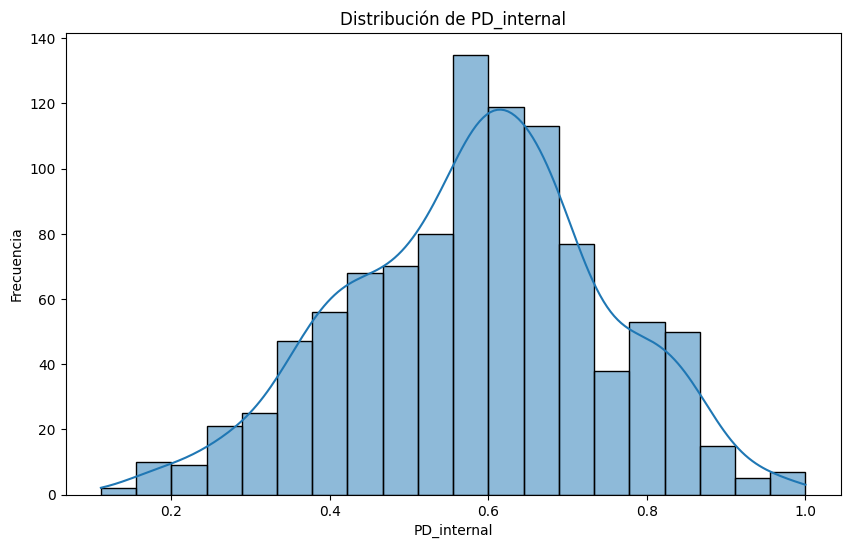

In [42]:
#plot de distribución de PD_internal
plt.figure(figsize=(10, 6))
sns.histplot(df['PD_internal'], bins=20, kde=True)
plt.title('Distribución de PD_internal')
plt.xlabel('PD_internal')
plt.ylabel('Frecuencia')
#podemos observar que la mayoría de los clientes tienen un PD_internal bajo,
# pero hay una cola hacia valores más altos, lo que indica que hay algunos clientes con un riesgo interno elevado.

In [43]:
import numpy as np
import pandas as pd
import os

df["Decision_credito"] = np.select(
    [
        df["PD_internal"] <= 0.5,
        (df["PD_internal"] > 0.5) & (df["PD_internal"] <= 0.65),
        df["PD_internal"] > 0.65
    ],
    [
        "Aprobado automatico",
        "Revision manual",
        "Rechazado"
    ],
    default="Sin clasificar"
)

df["Score_version"] = "Credit_risk_v1"

# 3) Resumen operativo
resumen = (
    df.groupby("Decision_credito")
      .agg(
          Clientes=("Decision_credito", "size"),
          PD_promedio=("PD_internal", "mean"),
          PD_min=("PD_internal", "min"),
          PD_max=("PD_internal", "max")
      )
)
resumen["Porcentaje"] = resumen["Clientes"] / len(df)

print("Resumen de decision:")
print(resumen.sort_values("PD_promedio"))
print("\nConteo:")
print(df["Decision_credito"].value_counts())

# 4) Export final
out_dir = r"C:\data_sciences\GIT\Credit_risk\Credit_risk\data\raw"
os.makedirs(out_dir, exist_ok=True)

csv_path = os.path.join(out_dir, "Credit_risk_v1.csv")
xlsx_path = os.path.join(out_dir, "Credit_risk_v1.xlsx")

df.to_csv(csv_path, index=False)
df.to_excel(xlsx_path, index=False)

print("\nArchivo CSV:", csv_path)
print("Archivo XLSX:", xlsx_path)


Resumen de decision:
                     Clientes  PD_promedio    PD_min    PD_max  Porcentaje
Decision_credito                                                          
Aprobado automatico       285     0.385103  0.110970  0.498695       0.285
Revision manual           373     0.580865  0.500163  0.648631       0.373
Rechazado                 342     0.753531  0.654919  1.000000       0.342

Conteo:
Decision_credito
Revision manual        373
Rechazado              342
Aprobado automatico    285
Name: count, dtype: int64

Archivo CSV: C:\data_sciences\GIT\Credit_risk\Credit_risk\data\raw\Credit_risk_v1.csv
Archivo XLSX: C:\data_sciences\GIT\Credit_risk\Credit_risk\data\raw\Credit_risk_v1.xlsx


In [44]:
df

,Sex,Age_group,Housing,Purpose,Risk_per_purpose,Credit amount,Duration,Financial_profile,Saving accounts,Checking account,...,Duration_estimated,Checking_score,Saving_score,Duration_score,Job_score,Risk_per_purpose_score,Internal_Risk_Score,PD_internal,Decision_credito,Score_version
0,male,66+,own,radio/TV,alto riesgo,1169,6,No_tiene / little,NaN,little,...,0-6,0.75,1.00,0.050697,0.3,1.0,3.100697,0.606228,Revision manual,Credit_risk_v1
1,female,0-25,own,radio/TV,alto riesgo,5951,48,little / moderate,little,moderate,...,43-48,0.50,0.75,0.614739,0.3,1.0,4.164739,0.814262,Rechazado,Credit_risk_v1
2,male,46-55,own,education,bajo riesgo,2096,12,little / No_tiene,little,NaN,...,7-12,1.00,0.75,0.116471,0.6,0.0,2.466471,0.482228,Aprobado automatico,Credit_risk_v1
3,male,36-45,free,furniture/equipment,alto riesgo,7882,42,little / little,little,little,...,37-42,0.75,0.75,0.523721,0.3,1.0,4.323721,0.845345,Rechazado,Credit_risk_v1
4,male,46-55,free,car,bajo riesgo,4870,24,little / little,little,little,...,19-24,0.75,0.75,0.267581,0.3,0.0,3.067581,0.599753,Revision manual,Credit_risk_v1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,female,26-35,own,furniture/equipment,alto riesgo,1736,12,little / No_tiene,little,NaN,...,7-12,1.00,0.75,0.116471,0.6,1.0,3.466471,0.677742,Rechazado,Credit_risk_v1
996,male,36-45,own,car,bajo riesgo,3857,30,little / little,little,little,...,25-30,0.75,0.75,0.349741,0.0,0.0,2.849741,0.557163,Revision manual,Credit_risk_v1
997,male,36-45,own,radio/TV,alto riesgo,804,12,little / No_tiene,little,NaN,...,7-12,1.00,0.75,0.116471,0.3,1.0,3.166471,0.619088,Revision manual,Credit_risk_v1
998,male,0-25,free,radio/TV,alto riesgo,1845,45,little / little,little,little,...,43-48,0.75,0.75,0.568926,0.3,1.0,3.368926,0.658670,Rechazado,Credit_risk_v1


In [45]:
import numpy as np

# 1) Crear etiqueta proxy desde tu PD_internal
# 0 = bajo riesgo, 1 = alto riesgo, NaN = zona gris (revisión manual)
df["default_12m"] = np.nan
df.loc[df["PD_internal"] <= 0.50, "default_12m"] = 0
df.loc[df["PD_internal"] > 0.65, "default_12m"] = 1

# 2) Dataset para entrenar (quitamos zona gris)
df_model = df.dropna(subset=["default_12m"]).copy()
df_model["default_12m"] = df_model["default_12m"].astype("int8")

print("Distribución etiqueta:")
print(df_model["default_12m"].value_counts(dropna=False))
print(f"Filas usadas: {len(df_model)} / {len(df)}")

# 3) Preparar X,y (evitar fuga de información)
cols_drop = ["default_12m", "Internal_Risk_Score", "PD_internal", "Decision_credito"]
X = df_model.drop(columns=[c for c in cols_drop if c in df_model.columns])
y = df_model["default_12m"]
print("Características (X):", X.columns.tolist())
print("Etiqueta (y):", y.name)


Distribución etiqueta:
default_12m
1    342
0    285
Name: count, dtype: int64
Filas usadas: 627 / 1000
Características (X): ['Sex', 'Age_group', 'Housing', 'Purpose', 'Risk_per_purpose', 'Credit amount', 'Duration', 'Financial_profile', 'Saving accounts', 'Checking account', 'Job_type', 'Duration_estimated', 'Checking_score', 'Saving_score', 'Duration_score', 'Job_score', 'Risk_per_purpose_score', 'Score_version']
Etiqueta (y): default_12m


In [46]:
# Evitar fuga/circularidad (target proxy viene de PD_internal)
drop_cols = [
    "default_12m", "Internal_Risk_Score", "PD_internal", "Decision_credito", "Score_version",
    "Checking_score", "Saving_score", "Duration_score", "Job_score", "Risk_per_purpose_score",
    "Financial_profile", "Duration_estimated", "Risk_per_purpose"
]
X = df_model.drop(columns=[c for c in drop_cols if c in df_model.columns], errors="ignore")
y = df_model["default_12m"].astype(int)

cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = X.select_dtypes(exclude=["object", "category"]).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

pre = ColumnTransformer([
    ("num", Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("sc", StandardScaler())
    ]), num_cols),
    ("cat", Pipeline([
        ("imp", SimpleImputer(strategy="most_frequent")),
        ("oh", OneHotEncoder(handle_unknown="ignore"))
    ]), cat_cols),
])

model = Pipeline([
    ("pre", pre),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42))
])

model.fit(X_train, y_train)

proba = model.predict_proba(X_test)[:, 1]
pred_05 = (proba >= 0.50).astype(int)

print("ROC-AUC:", round(roc_auc_score(y_test, proba), 4))
print("PR-AUC :", round(average_precision_score(y_test, proba), 4))
print("\nMatriz (t=0.50):\n", confusion_matrix(y_test, pred_05))
print("\nReporte (t=0.50):\n", classification_report(y_test, pred_05, digits=4))


ROC-AUC: 0.9898
PR-AUC : 0.9925

Matriz (t=0.50):
 [[70  1]
 [ 8 78]]

Reporte (t=0.50):
               precision    recall  f1-score   support

           0     0.8974    0.9859    0.9396        71
           1     0.9873    0.9070    0.9455        86

    accuracy                         0.9427       157
   macro avg     0.9424    0.9464    0.9425       157
weighted avg     0.9467    0.9427    0.9428       157



In [47]:
cost_fp, cost_fn = 1, 5
ths = np.linspace(0.05, 0.95, 181)

best_t, best_cost = None, 1e18
for t in ths:
    pred = (proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    cost = fp * cost_fp + fn * cost_fn
    if cost < best_cost:
        best_cost, best_t = cost, t

print(f"Mejor umbral por costo: {best_t:.3f} | costo={best_cost:.1f}")

pred_best = (proba >= best_t).astype(int)
print("\nMatriz (t óptimo):\n", confusion_matrix(y_test, pred_best))
print("\nReporte (t óptimo):\n", classification_report(y_test, pred_best, digits=4))


Mejor umbral por costo: 0.220 | costo=13.0

Matriz (t óptimo):
 [[63  8]
 [ 1 85]]

Reporte (t óptimo):
               precision    recall  f1-score   support

           0     0.9844    0.8873    0.9333        71
           1     0.9140    0.9884    0.9497        86

    accuracy                         0.9427       157
   macro avg     0.9492    0.9378    0.9415       157
weighted avg     0.9458    0.9427    0.9423       157



In [48]:
df.to_excel("data/raw/german_credit_Final.xlsx", index=False)

In [49]:
df

,Sex,Age_group,Housing,Purpose,Risk_per_purpose,Credit amount,Duration,Financial_profile,Saving accounts,Checking account,...,Checking_score,Saving_score,Duration_score,Job_score,Risk_per_purpose_score,Internal_Risk_Score,PD_internal,Decision_credito,Score_version,default_12m
0,male,66+,own,radio/TV,alto riesgo,1169,6,No_tiene / little,NaN,little,...,0.75,1.00,0.050697,0.3,1.0,3.100697,0.606228,Revision manual,Credit_risk_v1,NaN
1,female,0-25,own,radio/TV,alto riesgo,5951,48,little / moderate,little,moderate,...,0.50,0.75,0.614739,0.3,1.0,4.164739,0.814262,Rechazado,Credit_risk_v1,1.0
2,male,46-55,own,education,bajo riesgo,2096,12,little / No_tiene,little,NaN,...,1.00,0.75,0.116471,0.6,0.0,2.466471,0.482228,Aprobado automatico,Credit_risk_v1,0.0
3,male,36-45,free,furniture/equipment,alto riesgo,7882,42,little / little,little,little,...,0.75,0.75,0.523721,0.3,1.0,4.323721,0.845345,Rechazado,Credit_risk_v1,1.0
4,male,46-55,free,car,bajo riesgo,4870,24,little / little,little,little,...,0.75,0.75,0.267581,0.3,0.0,3.067581,0.599753,Revision manual,Credit_risk_v1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,female,26-35,own,furniture/equipment,alto riesgo,1736,12,little / No_tiene,little,NaN,...,1.00,0.75,0.116471,0.6,1.0,3.466471,0.677742,Rechazado,Credit_risk_v1,1.0
996,male,36-45,own,car,bajo riesgo,3857,30,little / little,little,little,...,0.75,0.75,0.349741,0.0,0.0,2.849741,0.557163,Revision manual,Credit_risk_v1,NaN
997,male,36-45,own,radio/TV,alto riesgo,804,12,little / No_tiene,little,NaN,...,1.00,0.75,0.116471,0.3,1.0,3.166471,0.619088,Revision manual,Credit_risk_v1,NaN
998,male,0-25,free,radio/TV,alto riesgo,1845,45,little / little,little,little,...,0.75,0.75,0.568926,0.3,1.0,3.368926,0.658670,Rechazado,Credit_risk_v1,1.0


In [50]:
df["Duration"].mean()

np.float64(20.903)